In [14]:
## EfficientNetB0 Model ##

In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models


In [3]:
df = pd.read_csv("final_dataset.csv")
train_df, val_df = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=42)

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    train_df,
    x_col='filepath',
    y_col='label',
    target_size=(64, 64),
    class_mode='categorical',
    batch_size=32
)

val_gen = datagen.flow_from_dataframe(
    val_df,
    x_col='filepath',
    y_col='label',
    target_size=(64, 64),
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

num_classes = len(train_gen.class_indices)


Found 42241 validated image filenames belonging to 7 classes.
Found 4694 validated image filenames belonging to 7 classes.


In [4]:
base_model = EfficientNetB0(include_top=False, input_shape=(64, 64, 3), weights='imagenet', pooling='avg')
base_model.trainable = False  # Freeze base initially

model = models.Sequential([
    base_model,
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,426 (16.73 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("efficientnet_best.h5", save_best_only=True)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)


c:\Users\devgo\OneDrive\Desktop\project\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.1482 - loss: 2.1677

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 187s 138ms/step - accuracy: 0.1481 - loss: 2.1676 - val_accuracy: 0.1429 - val_loss: 1.9460
Epoch 2/15
1320/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1470 - loss: 1.9471

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 49s 37ms/step - accuracy: 0.1470 - loss: 1.9471 - val_accuracy: 0.1429 - val_loss: 1.9460
Epoch 3/15
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 50s 38ms/step - accuracy: 0.1509 - loss: 1.9455 - val_accuracy: 0.1429 - val_loss: 1.9461
Epoch 4/15
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 52s 39ms/step - accuracy: 0.1505 - loss: 1.9450 - val_accuracy: 0.1429 - val_loss: 1.9461
Epoch 5/15
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 52s 39ms/step - accuracy: 0.1518 - loss: 1.9444 - val_accuracy: 0.1429 - val_loss: 1.9464
Epoch 6/15
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 110s 84ms/step - accuracy: 0.1575 - loss: 1.9429 - val_accuracy: 0.1429 - val_loss: 1.9465
Epoch 7/15
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 58s 44ms/step - accuracy: 0.1594 - loss: 1.9425 - val_accuracy: 0.1429 - val_loss: 1.9467


In [7]:
# Unfreeze the base EfficientNet
base_model.trainable = True

# Compile again with lower LR
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Continue training
fine_tune_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 257s 179ms/step - accuracy: 0.9317 - loss: 0.2017 - val_accuracy: 0.8240 - val_loss: 0.5425
Epoch 2/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 239s 181ms/step - accuracy: 0.9353 - loss: 0.1913 - val_accuracy: 0.8888 - val_loss: 0.3216
Epoch 3/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 238s 180ms/step - accuracy: 0.9368 - loss: 0.1835 - val_accuracy: 0.8943 - val_loss: 0.3162
Epoch 4/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9390 - loss: 0.1753

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 240s 182ms/step - accuracy: 0.9390 - loss: 0.1753 - val_accuracy: 0.9340 - val_loss: 0.1988
Epoch 5/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 240s 182ms/step - accuracy: 0.9443 - loss: 0.1618 - val_accuracy: 0.9167 - val_loss: 0.2469
Epoch 6/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 240s 181ms/step - accuracy: 0.9462 - loss: 0.1552 - val_accuracy: 0.8296 - val_loss: 0.4882
Epoch 7/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9489 - loss: 0.1448

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 239s 181ms/step - accuracy: 0.9489 - loss: 0.1448 - val_accuracy: 0.9367 - val_loss: 0.1840
Epoch 8/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 240s 182ms/step - accuracy: 0.9495 - loss: 0.1443 - val_accuracy: 0.4989 - val_loss: 1.7260
Epoch 9/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 240s 182ms/step - accuracy: 0.9525 - loss: 0.1350 - val_accuracy: 0.6466 - val_loss: 1.1215
Epoch 10/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 240s 182ms/step - accuracy: 0.9549 - loss: 0.1251 - val_accuracy: 0.8752 - val_loss: 0.3522
Epoch 11/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 240s 182ms/step - accuracy: 0.9577 - loss: 0.1190 - val_accuracy: 0.8110 - val_loss: 0.6300
Epoch 12/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9583 - loss: 0.1202

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 239s 181ms/step - accuracy: 0.9583 - loss: 0.1202 - val_accuracy: 0.9457 - val_loss: 0.1633
Epoch 13/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 239s 181ms/step - accuracy: 0.9610 - loss: 0.1105 - val_accuracy: 0.9207 - val_loss: 0.2449
Epoch 14/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 239s 181ms/step - accuracy: 0.9615 - loss: 0.1070 - val_accuracy: 0.9465 - val_loss: 0.1705
Epoch 15/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 239s 181ms/step - accuracy: 0.9631 - loss: 0.1031 - val_accuracy: 0.9165 - val_loss: 0.2628
Epoch 16/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 240s 182ms/step - accuracy: 0.9643 - loss: 0.0965 - val_accuracy: 0.3707 - val_loss: 4.2970
Epoch 17/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 240s 182ms/step - accuracy: 0.9648 - loss: 0.0952 - val_accuracy: 0.8892 - val_loss: 0.3554


In [8]:
loss, acc = model.evaluate(val_gen)
print(f"✅ Final Validation Accuracy after Fine-Tuning: {acc:.4f}")


147/147 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9427 - loss: 0.1629
✅ Final Validation Accuracy after Fine-Tuning: 0.9457


In [9]:
model.save("efficientnet_finetuned_model.h5")


In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get ground truth and predictions
y_true = val_gen.classes  # Actual labels
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)  # Predicted class indices

# Get class names
class_labels = list(val_gen.class_indices.keys())

# Print classification report (includes precision, recall, F1-score)
report = classification_report(y_true, y_pred, target_names=class_labels, digits=4)
print("📋 Classification Report:\n")
print(report)


147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step
📋 Classification Report:

              precision    recall  f1-score   support

       AKIEC     0.9747    0.9776    0.9762       670
         BCC     0.9729    0.9642    0.9685       670
         BKL     0.9240    0.8882    0.9058       671
          DF     0.9866    0.9866    0.9866       671
         MEL     0.9415    0.8867    0.9133       671
          NV     0.8399    0.9239    0.8799       670
        VASC     0.9896    0.9925    0.9911       671

    accuracy                         0.9457      4694
   macro avg     0.9470    0.9457    0.9459      4694
weighted avg     0.9470    0.9457    0.9459      4694



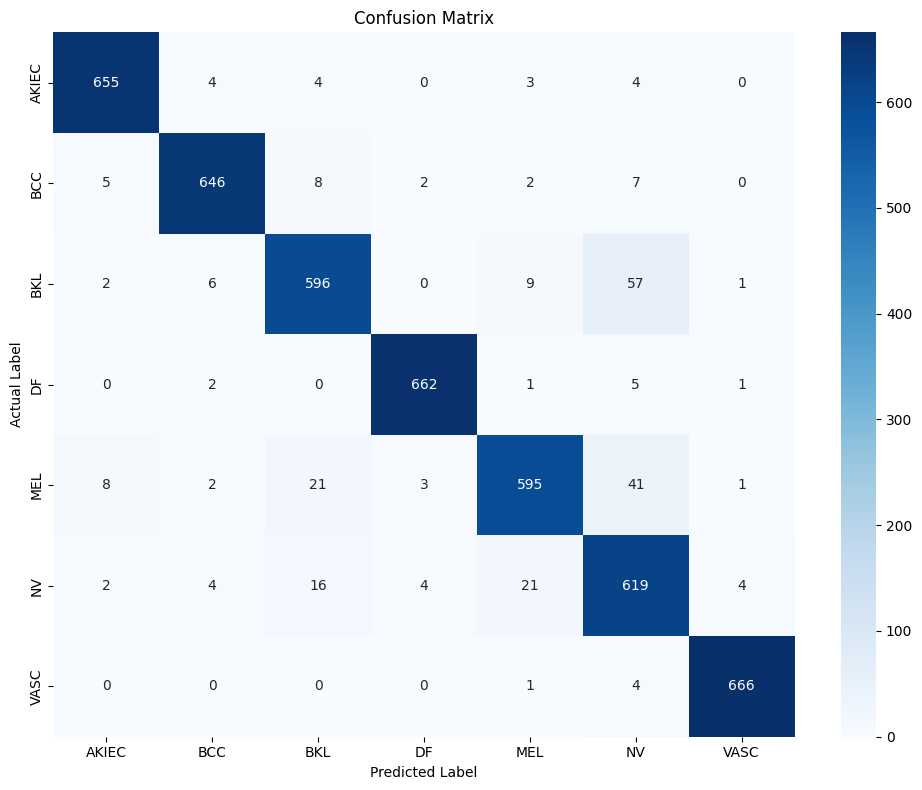

In [11]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot it
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


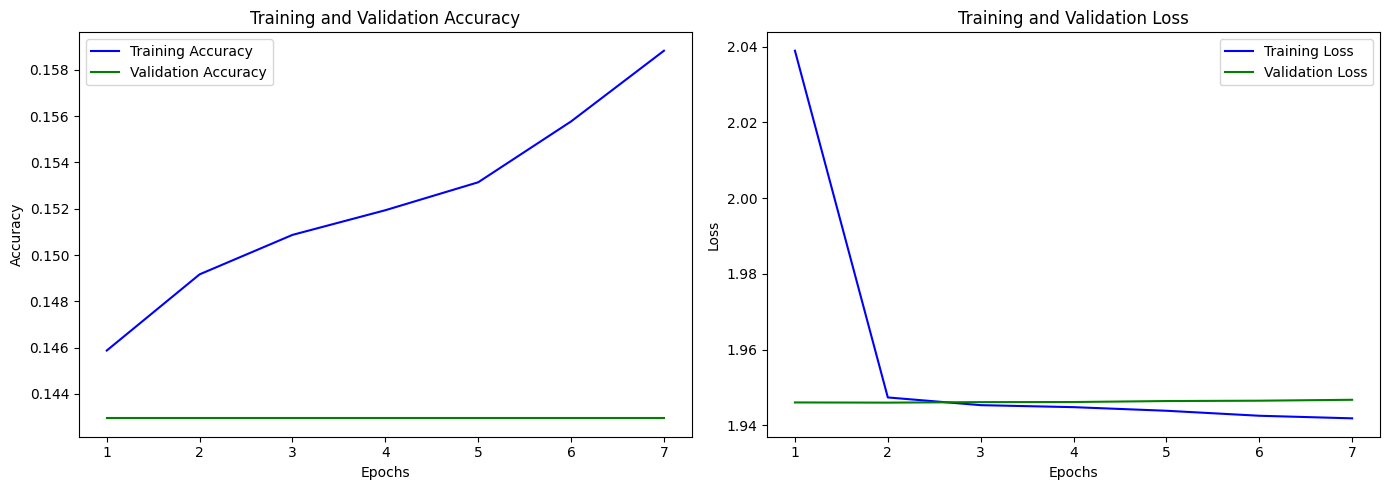

In [12]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'g-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'g-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call it after training
plot_training_history(history)


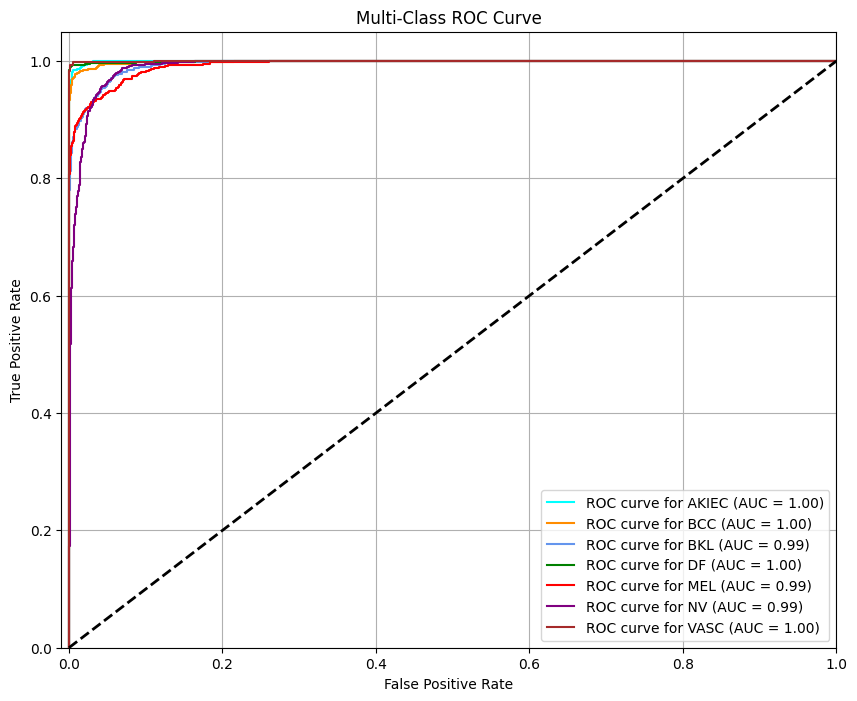

In [13]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from itertools import cycle

def plot_multiclass_roc_auc(y_true, y_pred_probs, class_labels):
    n_classes = len(class_labels)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown'])

    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color,
                 label=f'ROC curve for {class_labels[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Call this using:
plot_multiclass_roc_auc(y_true, y_pred_probs, class_labels)


In [15]:
import os
import numpy as np
from datetime import datetime
from sklearn.metrics import classification_report, roc_auc_score
from tensorflow.keras.utils import to_categorical

def evaluate_and_log_model_plain(y_true, y_pred_probs, class_labels, model_name="MyModel", log_file="model_report.txt"):
    # Convert to class predictions
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.array(y_true)
    y_true_bin = to_categorical(y_true, num_classes=len(class_labels))

    # Get classification metrics
    report = classification_report(y_true, y_pred, target_names=class_labels, digits=4, output_dict=True)
    accuracy = report["accuracy"]
    f1 = report["weighted avg"]["f1-score"]
    precision = report["weighted avg"]["precision"]
    recall = report["weighted avg"]["recall"]
    
    # Try ROC AUC
    try:
        roc_auc = roc_auc_score(y_true_bin, y_pred_probs, average='weighted', multi_class='ovr')
        roc_auc_str = f"{roc_auc:.4f}"
    except:
        roc_auc_str = "N/A"

    # Create log string
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    log_entry = f"""
==========================
Timestamp : {timestamp}
Model     : {model_name}
Accuracy  : {accuracy:.4f}
Precision : {precision:.4f}
Recall    : {recall:.4f}
F1 Score  : {f1:.4f}
ROC AUC   : {roc_auc_str}
==========================

"""

    # Append to text file (plain encoding)
    with open(log_file, "a") as f:
        f.write(log_entry)

    print("Model evaluation logged successfully.")
    print(log_entry)


In [16]:
# After training
y_true = val_gen.classes
y_pred_probs = model.predict(val_gen)
class_labels = list(val_gen.class_indices.keys())

# Log model evaluation
evaluate_and_log_model_plain(y_true, y_pred_probs, class_labels, model_name="EfficientNetB0")


147/147 ━━━━━━━━━━━━━━━━━━━━ 17s 116ms/step
Model evaluation logged successfully.

Timestamp : 2025-07-01 21:11:16
Model     : EfficientNetB0
Accuracy  : 0.9457
Precision : 0.9470
Recall    : 0.9457
F1 Score  : 0.9459
ROC AUC   : 0.9966


